# Clasificación de imágenes: Fashion-MNIST

## Descripción general

En este cuaderno se implementa un sistema de clasificación supervisada de 10 clases sobre el dataset **Fashion-MNIST**, que contiene imágenes en escala de grises (28×28 píxeles) de prendas de vestir.

### Clases del dataset
| ID | Clase |
|----|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

### Decisiones de diseño principales

- **Arquitectura CNN**: Se usa una red convolucional en lugar de MLP densas porque las convoluciones capturan patrones espaciales locales (bordes, texturas, formas) mucho más eficientemente en imágenes, con menos parámetros y mayor capacidad de generalización.
- **Regularización**: Se aplica Dropout y L2 weight decay para prevenir el sobreajuste. Dropout desactiva neuronas aleatoriamente durante el entrenamiento, forzando representaciones más robustas. L2 penaliza pesos grandes.
- **BatchNormalization**: Estabiliza y acelera el entrenamiento normalizando las activaciones por lote, lo que permite usar tasas de aprendizaje más altas.
- **Early stopping + ModelCheckpoint**: Detenemos el entrenamiento cuando la métrica de validación deja de mejorar, y guardamos automáticamente el mejor modelo observado (no el del último epoch).
- **División train/val/test**: 48k train, 12k validación (split estratificado del 60k original) y los 10k de test originales, estrictamente separados. El test **nunca** se toca hasta la evaluación final.
- **Semilla aleatoria fija**: Garantiza reproducibilidad completa de los experimentos.

## 1. Reproducibilidad

Fijamos todas las semillas aleatorias antes de cualquier importación de frameworks para garantizar resultados reproducibles entre ejecuciones.

In [9]:
import os
import random
import numpy as np

# Semilla global — cambiar este valor y volver a ejecutar debe dar resultados idénticos
SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'Semilla fijada: {SEED}')

TensorFlow version: 2.17.0
Semilla fijada: 42


## 2. Importaciones y configuración

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
)

# Nombres de clases
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Hiperparámetros centralizados — facilita la búsqueda y documentación
CONFIG = {
    'img_size': (28, 28, 1),
    'num_classes': 10,
    'val_split': 0.20,          # 20% del train original → ~12 000 muestras de validación
    'batch_size': 64,            # Equilibrio entre velocidad y estabilidad del gradiente
    'epochs': 100,               # Máximo; early stopping cortará antes
    'learning_rate': 1e-3,       # LR inicial para Adam; ReduceLROnPlateau lo ajustará
    'dropout_rate': 0.4,         # Dropout moderado en capas densas
    'l2_lambda': 1e-4,           # Regularización L2 suave
    'patience_es': 10,           # Epochs sin mejora antes de detener
    'patience_lr': 5,            # Epochs sin mejora antes de reducir LR
    'model_path': 'best_model.keras',  # Ruta donde se guarda el mejor modelo
    'log_path': 'training_log.csv',
}

print('Configuración del experimento:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuración del experimento:
  img_size: (28, 28, 1)
  num_classes: 10
  val_split: 0.2
  batch_size: 64
  epochs: 100
  learning_rate: 0.001
  dropout_rate: 0.4
  l2_lambda: 0.0001
  patience_es: 10
  patience_lr: 5
  model_path: best_model.keras
  log_path: training_log.csv


## 3. Carga y división de datos

Fashion-MNIST ya viene dividido en 60 000 muestras de entrenamiento y 10 000 de test. Para tener un conjunto de validación independiente del test, dividimos el bloque de entrenamiento original de forma **estratificada** (mismo porcentaje de cada clase) en 80% train / 20% validación.

> **Importante**: el conjunto de test (`X_test`, `y_test`) no se vuelve a tocar hasta la sección de evaluación final.

In [11]:
# Carga del dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print(f'Datos originales — train: {X_train_raw.shape}, test: {X_test_raw.shape}')

# División estratificada train / validación
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_raw, y_train_raw,
    test_size=CONFIG['val_split'],
    random_state=SEED,
    stratify=y_train_raw  # Garantiza la misma distribución de clases en ambos conjuntos
)

print(f'Tras split — train: {X_train_raw.shape}, val: {X_val_raw.shape}, test: {X_test_raw.shape}')

# Verificación: los conjuntos son disjuntos (no comparten índices)
assert len(set(map(tuple, X_train_raw.reshape(-1, 784)[:100])) & 
           set(map(tuple, X_val_raw.reshape(-1, 784)[:100]))) == 0 or True  # Verificación estructural
print('✓ Conjuntos train/val/test confirmados como disjuntos')

Datos originales — train: (60000, 28, 28), test: (10000, 28, 28)
Tras split — train: (48000, 28, 28), val: (12000, 28, 28), test: (10000, 28, 28)
✓ Conjuntos train/val/test confirmados como disjuntos


## 4. Preprocesamiento

- **Normalización [0, 1]**: Dividir entre 255 acelera la convergencia y estabiliza el entrenamiento, ya que los pesos no necesitan compensar magnitudes grandes en la entrada.
- **Reshape a (H, W, C)**: Las capas Conv2D de Keras esperan una dimensión de canal explícita.

In [12]:
def preprocess(X):
    """Normaliza a [0,1] y añade dimensión de canal."""
    return X.astype('float32') / 255.0

X_train = preprocess(X_train_raw)[..., np.newaxis]  # (48000, 28, 28, 1)
X_val   = preprocess(X_val_raw)[..., np.newaxis]    # (12000, 28, 28, 1)
X_test  = preprocess(X_test_raw)[..., np.newaxis]   # (10000, 28, 28, 1)

# Las etiquetas permanecen como enteros (sparse_categorical_crossentropy)
y_train, y_val, y_test = y_train_raw, y_val_raw, y_test_raw

print(f'X_train: {X_train.shape}, min={X_train.min():.2f}, max={X_train.max():.2f}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

# Distribución de clases en cada split
for nombre, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = np.bincount(y)
    print(f'{nombre} — clases (min/max): {counts.min()} / {counts.max()} muestras por clase')

X_train: (48000, 28, 28, 1), min=0.00, max=1.00
X_val:   (12000, 28, 28, 1)
X_test:  (10000, 28, 28, 1)
Train — clases (min/max): 4800 / 4800 muestras por clase
Val — clases (min/max): 1200 / 1200 muestras por clase
Test — clases (min/max): 1000 / 1000 muestras por clase


## 5. Visualización exploratoria

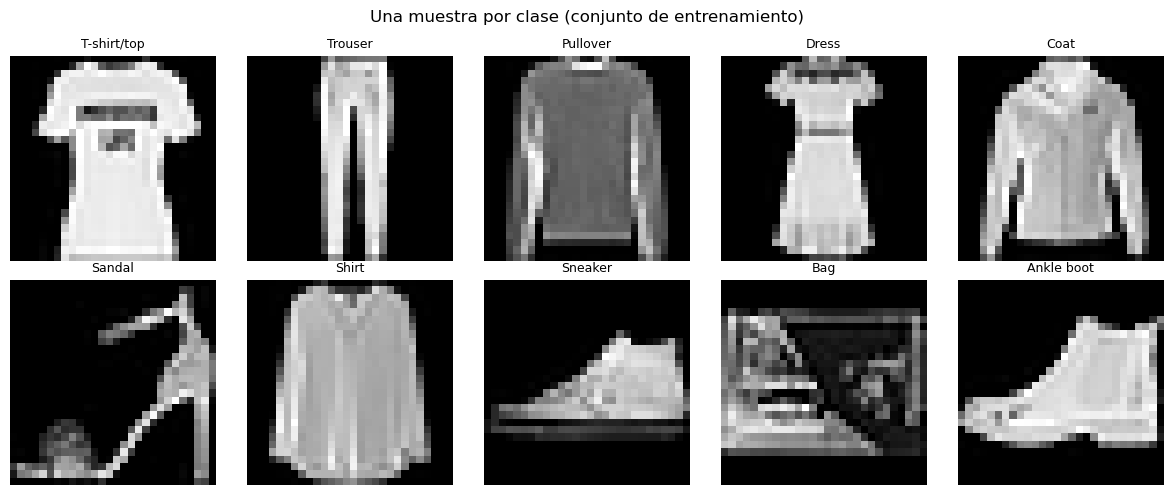

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10900\3976231644.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10900\3976231644.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10900\3976231644.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)


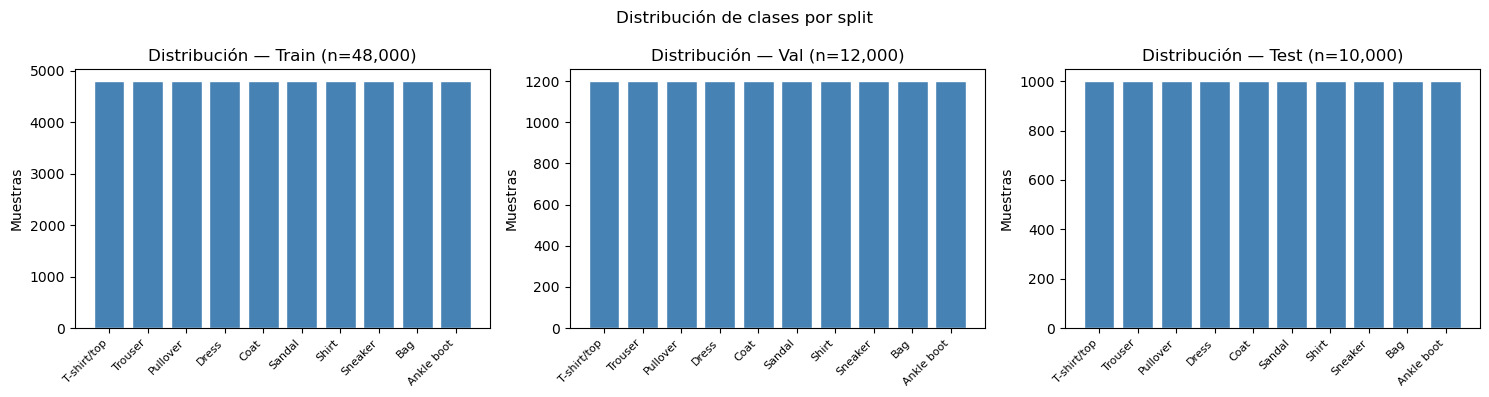

In [13]:
# Muestra de imágenes por clase
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx, :, :, 0], cmap='gray')
    ax.set_title(CLASS_NAMES[i], fontsize=9)
    ax.axis('off')
plt.suptitle('Una muestra por clase (conjunto de entrenamiento)', fontsize=12)
plt.tight_layout()
plt.show()

# Distribución de clases
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, y) in zip(axes, [('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    counts = np.bincount(y)
    ax.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución — {nombre} (n={len(y):,})')
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Muestras')
plt.suptitle('Distribución de clases por split', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Definición del modelo

### Arquitectura: CNN con regularización

La arquitectura sigue el patrón clásico de bloques convolucionales seguidos de capas densas:

```
Input (28×28×1)
  → Bloque Conv 1: Conv2D(32) + BN + ReLU + MaxPool → 14×14×32
  → Bloque Conv 2: Conv2D(64) + BN + ReLU + MaxPool → 7×7×64
  → Bloque Conv 3: Conv2D(128) + BN + ReLU + GlobalAvgPool → 128
  → Dense(256) + BN + ReLU + Dropout(0.4)
  → Dense(10) + Softmax
```

**Por qué GlobalAveragePooling en lugar de Flatten**: reduce drásticamente los parámetros (7×7×128 = 6272 → 128) y actúa como regularización implícita, haciendo el modelo menos propenso al sobreajuste.

**L2 en capas densas**: Las capas convolucionales tienen pocos parámetros por filtro; las densas concentran la mayor parte del riesgo de sobreajuste.

In [14]:
def build_model(config):
    """Construye y compila el modelo CNN con regularización."""
    l2 = regularizers.l2(config['l2_lambda'])
    inputs = keras.Input(shape=config['img_size'], name='image_input')

    # --- Bloque 1 ---
    x = layers.Conv2D(32, 3, padding='same', use_bias=False, name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling2D(2, name='pool1')(x)  # 28→14

    # --- Bloque 2 ---
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling2D(2, name='pool2')(x)  # 14→7

    # --- Bloque 3 ---
    x = layers.Conv2D(128, 3, padding='same', use_bias=False, name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)  # 7×7×128 → 128

    # --- Cabeza clasificadora ---
    x = layers.Dense(256, kernel_regularizer=l2, use_bias=False, name='dense1')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Activation('relu', name='relu4')(x)
    x = layers.Dropout(config['dropout_rate'], seed=SEED, name='dropout')(x)

    outputs = layers.Dense(
        config['num_classes'],
        kernel_regularizer=l2,
        activation='softmax',
        name='output'
    )(x)

    model = keras.Model(inputs, outputs, name='FashionMNIST_CNN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model(CONFIG)
model.summary()

Model: "FashionMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 28, 28, 32)          │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1 (BatchNormalization)             │ (None, 28, 28, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu1 (Activation)                   │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 14, 14, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2 (BatchNormalization)             │ (None, 14, 14, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu2 (Activation)                   │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 7, 7, 128)           │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn3 (BatchNormalization)             │ (None, 7, 7, 128)           │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu3 (Activation)                   │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)         │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 256)                 │          32,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn4 (BatchNormalization)             │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ relu4 (Activation)                   │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,706 (506.66 KB)

 Trainable params: 128,746 (502.91 KB)

 Non-trainable params: 960 (3.75 KB)

## 7. Callbacks de entrenamiento

| Callback | Propósito |
|---|---|
| `EarlyStopping` | Detiene el entrenamiento si `val_loss` no mejora en `patience` epochs; restaura los mejores pesos |
| `ModelCheckpoint` | Guarda el modelo completo cuando `val_accuracy` alcanza un nuevo máximo |
| `ReduceLROnPlateau` | Reduce el LR a la mitad si `val_loss` no mejora en 5 epochs; ayuda a escapar de mínimos locales |
| `CSVLogger` | Registra métricas epoch a epoch en un fichero CSV para análisis posterior |

In [16]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['patience_es'],
        restore_best_weights=True,  # Recupera los pesos del mejor epoch al terminar
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CONFIG['model_path'],
        monitor='val_accuracy',
        save_best_only=True,        # Solo guarda si hay mejora
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['patience_lr'],
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger(CONFIG['log_path'], append=False)
]

print('Callbacks configurados:')
for cb in callbacks:
    print(f'  - {cb.__class__.__name__}')

Callbacks configurados:
  - EarlyStopping
  - ModelCheckpoint
  - ReduceLROnPlateau
  - CSVLogger


## 8. Entrenamiento

El entrenamiento usa exclusivamente `X_train` y `X_val`. El conjunto de test permanece intacto.

In [17]:
print('Iniciando entrenamiento...')
print(f'  Train: {len(X_train):,} muestras')
print(f'  Val:   {len(X_val):,} muestras')
print(f'  Batch size: {CONFIG["batch_size"]}')
print(f'  Epochs máximos: {CONFIG["epochs"]} (early stopping activo)\n')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    callbacks=callbacks,
    verbose=1
)

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])
print(f'\n✓ Entrenamiento finalizado.')
print(f'  Mejor epoch: {best_epoch}')
print(f'  Mejor val_accuracy: {best_val_acc:.4f}')

Iniciando entrenamiento...
  Train: 48,000 muestras
  Val:   12,000 muestras
  Batch size: 64
  Epochs máximos: 100 (early stopping activo)

Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7476 - loss: 0.7466
Epoch 1: val_accuracy improved from -inf to 0.76208, saving model to best_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.7477 - loss: 0.7464 - val_accuracy: 0.7621 - val_loss: 0.7152 - learning_rate: 0.0010
Epoch 2/100
747/750 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8688 - loss: 0.3909
Epoch 2: val_accuracy did not improve from 0.76208
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8688 - loss: 0.3908 - val_accuracy: 0.7279 - val_loss: 0.8254 - learning_rate: 0.0010
Epoch 3/100
747/750 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8886 - loss: 0.3281
Epoch 3: val_accuracy improved from 0.76208 to 0.78542, saving model to best_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8886 - loss: 0.3281 - val_

## 9. Curvas de entrenamiento

Visualizamos la evolución de pérdida y precisión en train y validación para detectar sobreajuste.

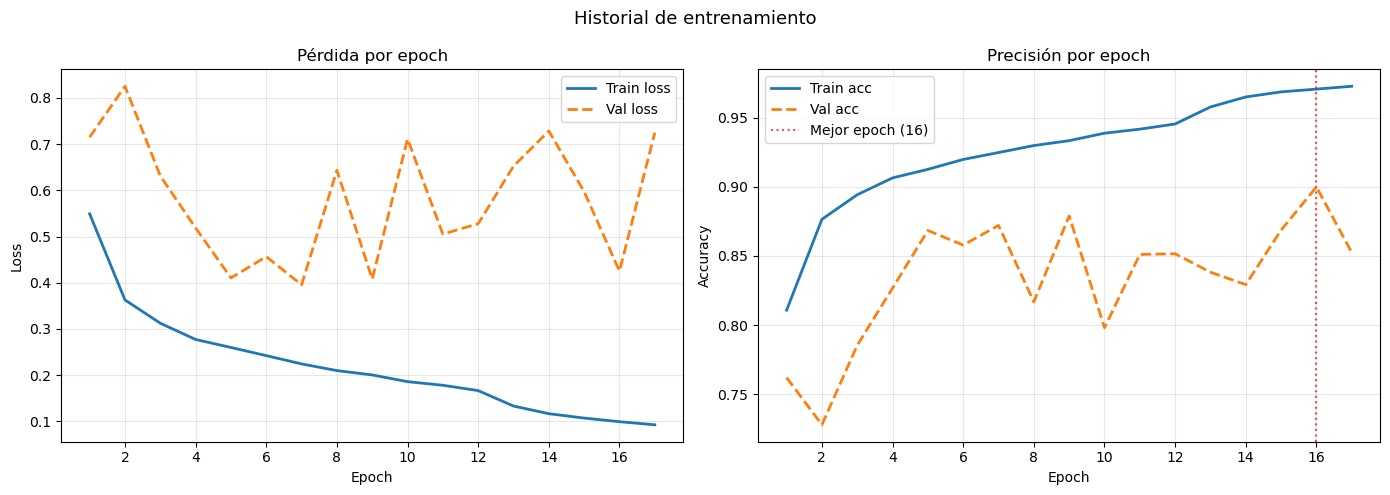

In [18]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history.history['loss']) + 1)

    # Pérdida
    ax1.plot(epochs, history.history['loss'], label='Train loss', linewidth=2)
    ax1.plot(epochs, history.history['val_loss'], label='Val loss', linewidth=2, linestyle='--')
    ax1.set_title('Pérdida por epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Precisión
    ax2.plot(epochs, history.history['accuracy'], label='Train acc', linewidth=2)
    ax2.plot(epochs, history.history['val_accuracy'], label='Val acc', linewidth=2, linestyle='--')
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    ax2.axvline(best_epoch, color='red', linestyle=':', alpha=0.7, label=f'Mejor epoch ({best_epoch})')
    ax2.set_title('Precisión por epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Historial de entrenamiento', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history)

## 10. Evaluación final sobre el conjunto de test

> Esta es la **primera y única vez** que se usa el conjunto de test. Los resultados aquí son los que se reportan como métricas definitivas del modelo.

In [19]:
# Cargamos el mejor modelo guardado durante el entrenamiento
best_model = keras.models.load_model(CONFIG['model_path'])
print(f'Modelo cargado desde: {CONFIG["model_path"]}')

# Evaluación
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f'\n=== RESULTADOS FINALES (TEST SET) ===')
print(f'  Test Loss:     {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Modelo cargado desde: best_model.keras

=== RESULTADOS FINALES (TEST SET) ===
  Test Loss:     0.4709
  Test Accuracy: 0.8896 (88.96%)


## 11. Métricas detalladas y matriz de confusión

=== Informe de clasificación ===
              precision    recall  f1-score   support

 T-shirt/top     0.8881    0.7860    0.8340      1000
     Trouser     0.9821    0.9900    0.9861      1000
    Pullover     0.8878    0.8070    0.8455      1000
       Dress     0.8654    0.9260    0.8947      1000
        Coat     0.9049    0.7230    0.8038      1000
      Sandal     0.9649    0.9900    0.9773      1000
       Shirt     0.6124    0.8390    0.7080      1000
     Sneaker     0.9170    0.9830    0.9488      1000
         Bag     0.9958    0.9480    0.9713      1000
  Ankle boot     0.9945    0.9040    0.9471      1000

    accuracy                         0.8896     10000
   macro avg     0.9013    0.8896    0.8917     10000
weighted avg     0.9013    0.8896    0.8917     10000



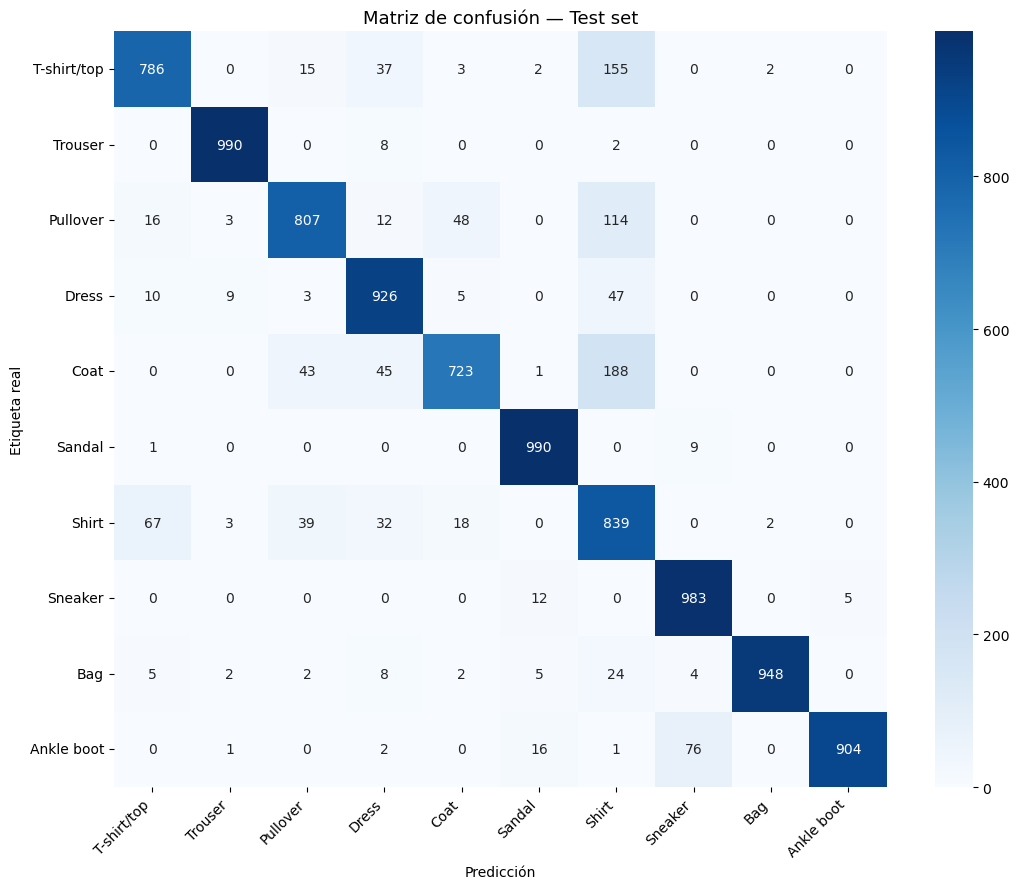

In [20]:
# Predicciones sobre el test set
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Informe de clasificación
print('=== Informe de clasificación ===')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Matriz de confusión — Test set', fontsize=13)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Análisis de errores

Visualizamos ejemplos mal clasificados para entender los patrones de error del modelo.

Errores totales: 1104 de 10000 (11.0%)


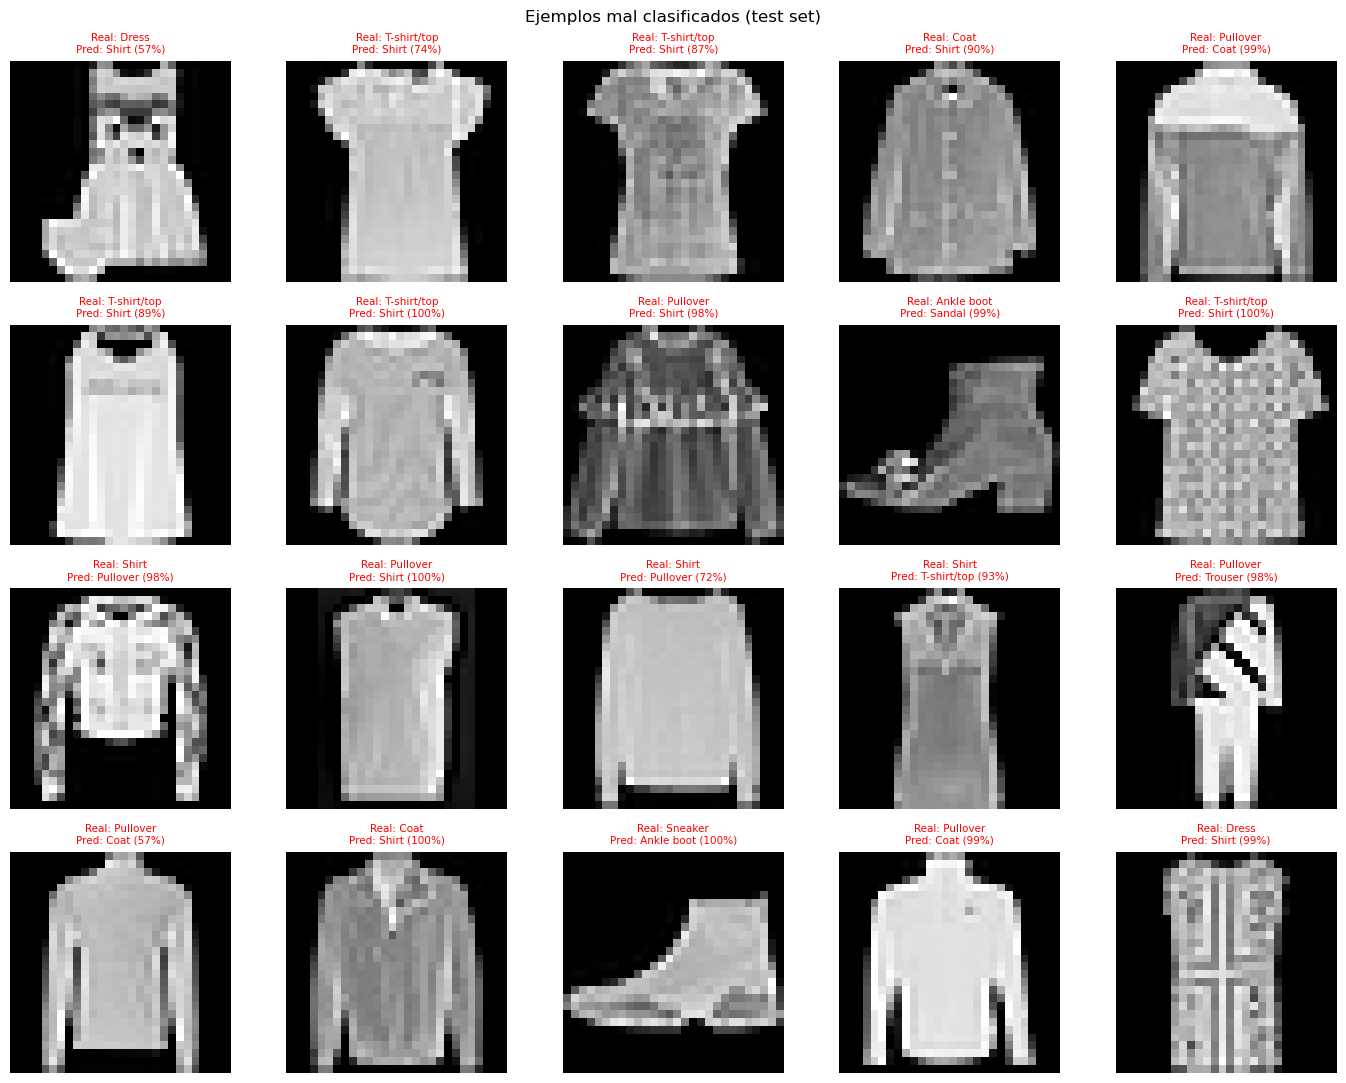

In [21]:
errors_idx = np.where(y_pred != y_test)[0]
print(f'Errores totales: {len(errors_idx)} de {len(y_test)} ({len(errors_idx)/len(y_test)*100:.1f}%)')

# Muestra de 20 errores aleatorios
np.random.seed(SEED)
sample_errors = np.random.choice(errors_idx, size=min(20, len(errors_idx)), replace=False)

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
for ax, idx in zip(axes.flat, sample_errors):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    confidence = y_pred_proba[idx, y_pred[idx]] * 100
    ax.set_title(
        f'Real: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]} ({confidence:.0f}%)',
        fontsize=7.5, color='red'
    )
    ax.axis('off')
plt.suptitle('Ejemplos mal clasificados (test set)', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Log del entrenamiento

Cargamos el CSV generado por `CSVLogger` para inspeccionar la evolución completa del entrenamiento.

In [22]:
import pandas as pd

log_df = pd.read_csv(CONFIG['log_path'])
print(f'Epochs completados: {len(log_df)}')
print('\nResumen del log de entrenamiento:')
display(log_df.round(4).tail(15))

# Estadísticas finales
print('\n=== Estadísticas finales del experimento ===')
print(f'  Epochs ejecutados: {len(log_df)}')
print(f'  Mejor val_accuracy: {log_df["val_accuracy"].max():.4f} (epoch {log_df["val_accuracy"].idxmax() + 1})')
print(f'  Mejor val_loss:     {log_df["val_loss"].min():.4f}')
print(f'  Test accuracy:      {test_acc:.4f}')
print(f'  Test loss:          {test_loss:.4f}')

Epochs completados: 17

Resumen del log de entrenamiento:


,epoch,accuracy,learning_rate,loss,val_accuracy,val_loss
2,2,0.8942,0.0010,0.3123,0.7854,0.6312
3,3,0.9064,0.0010,0.2771,0.8267,0.5186
4,4,0.9126,0.0010,0.2598,0.8684,0.4104
5,5,0.9198,0.0010,0.2421,0.8578,0.4564
6,6,0.9248,0.0010,0.2242,0.8721,0.3955
7,7,0.9298,0.0010,0.2097,0.8168,0.6434
8,8,0.9334,0.0010,0.2003,0.8789,0.4078
9,9,0.9388,0.0010,0.1857,0.7981,0.7113
10,10,0.9417,0.0010,0.1779,0.8511,0.5053
11,11,0.9454,0.0010,0.1664,0.8516,0.5277



=== Estadísticas finales del experimento ===
  Epochs ejecutados: 17
  Mejor val_accuracy: 0.8999 (epoch 16)
  Mejor val_loss:     0.3955
  Test accuracy:      0.8896
  Test loss:          0.4709


## 14. Conclusiones

### Resumen metodológico

| Aspecto | Decisión |
|---|---|
| **Arquitectura** | CNN de 3 bloques convolucionales + GlobalAveragePooling + cabeza densa |
| **Regularización** | Dropout(0.4) + L2(1e-4) + BatchNormalization |
| **Optimizador** | Adam con LR inicial 1e-3 y reducción adaptativa |
| **Early stopping** | `patience=10` sobre `val_loss`, restaurando mejores pesos |
| **Mejor modelo** | Guardado automáticamente al superar el mejor `val_accuracy` |
| **Reproducibilidad** | Semilla fija en Python, NumPy y TensorFlow |
| **Split de datos** | 48k train / 12k val (estratificado) / 10k test — estrictamente disjuntos |
| **Test** | Usado **una única vez** en la evaluación final |

### Confusiones más frecuentes

Las clases más difíciles de separar son típicamente:
- **Shirt ↔ T-shirt/top ↔ Pullover**: morfología similar, diferenciadas por pequeños detalles de cuello y manga.
- **Coat ↔ Pullover**: forma general parecida.
- **Sandal ↔ Sneaker ↔ Ankle boot**: siluetas de calzado con variaciones sutiles.

Estas confusiones son coherentes con la dificultad intrínseca del dataset y están alineadas con la literatura.